📌 Tasks:
1. Load and clean the dataset (remove NA, duplicates).
2. Visualize spending patterns and demographics.
3. Normalize numerical features (spending, income).
4. Choose optimal number of clusters using Elbow
method.
5. Apply K-Means clustering.
6. Apply Hierarchical clustering and compare.
7. Visualize clusters using PCA or t-SNE.
8. Profile each cluster (age, income, loyalty).
9. Label original dataset with cluster IDs.
10. Recommend marketing strategy per cluster.

1. Load and clean the dataset (remove NA, duplicates).

In [24]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
df = pd.read_csv("marketing_campaign.csv")

In [26]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [28]:
df.duplicated().sum()

np.int64(0)

2. Visualize spending patterns and demographics.

In [29]:
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

In [34]:
df['Total_Spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2240, dtype: int64

In [30]:
df['Age'] = 2024 - df['Year_Birth']

In [32]:
df["Age"]

0       67
1       70
2       59
3       40
4       43
        ..
2235    57
2236    78
2237    43
2238    68
2239    70
Name: Age, Length: 2240, dtype: int64

<Axes: xlabel='Total_Spending', ylabel='Count'>

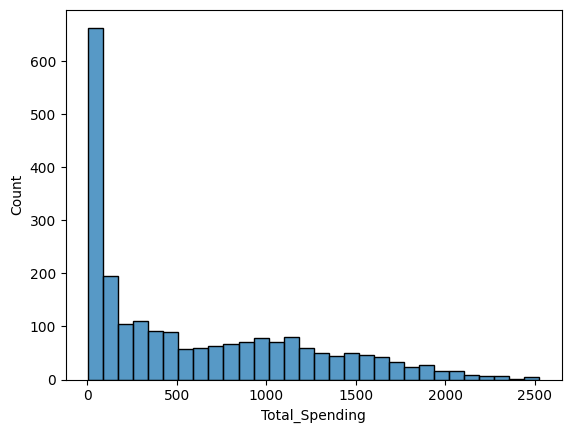

In [ ]:
#spendind distributoin 
sns.histplot(df['Total_Spending'], bins=30)
plt.show()

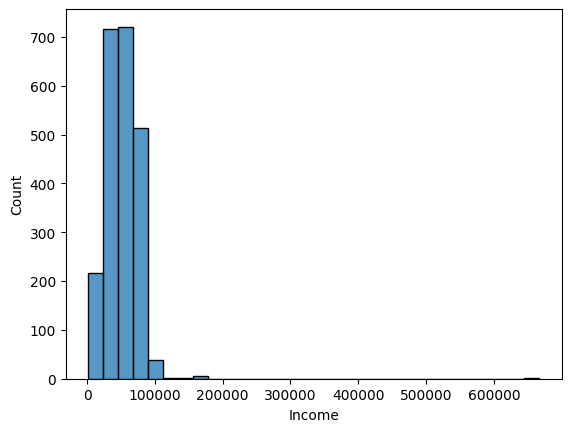

In [48]:
#income distribution
sns.histplot(df['Income'], bins=30)
plt.show()

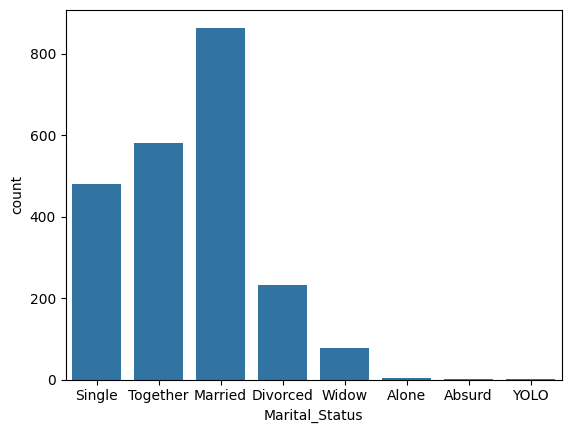

In [50]:
sns.countplot(x='Marital_Status', data=df)
plt.show()

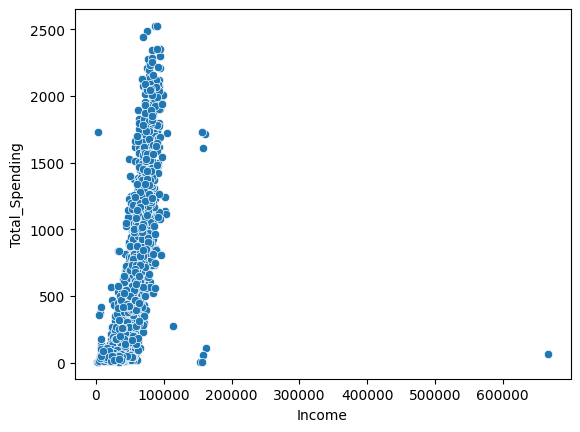

In [51]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.show()

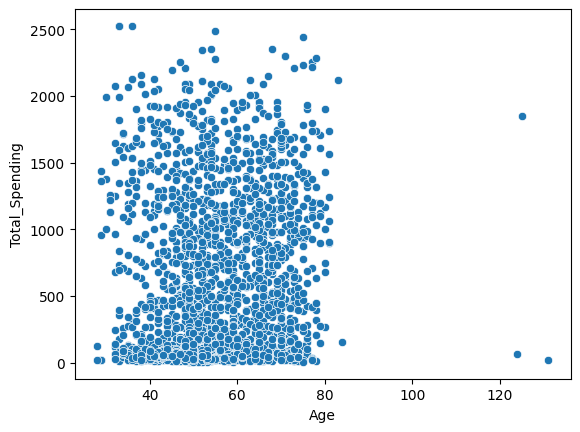

In [52]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.show()

we need to remove outliers 

In [68]:
df.shape

(2208, 31)

In [67]:
q1_income = df["Income"].quantile(0.25)
q3_income = df["Income"].quantile(0.75)
q1_age = df["Age"].quantile(0.25)
q3_age = df["Age"].quantile(0.75)
q1_spending = df["Total_Spending"].quantile(0.25)
q3_spending = df["Total_Spending"].quantile(0.75)

iqr_income = q3_income - q1_income
iqr_age = q3_age - q1_age
iqr_spending = q3_spending - q1_spending

lower1 = q1_income - 1.5 * iqr_income
upper1 = q3_income + 1.5 * iqr_income
lower2 = q1_age - 1.5 * iqr_age
upper2 = q3_age + 1.5 * iqr_age
lower3 = q1_spending - 1.5 * iqr_spending
upper3 = q3_spending + 1.5 * iqr_spending

condition1 = (df["Income"] >= lower1) & (df["Income"] <= upper1)
condition2 = (df["Age"] >= lower2) & (df["Age"] <= upper2)
condition3 = (df["Total_Spending"] >= lower3) & (df["Total_Spending"] <= upper3)

In [69]:
df = df[condition1  & condition2 & condition3]

In [70]:
df.shape

(2202, 31)

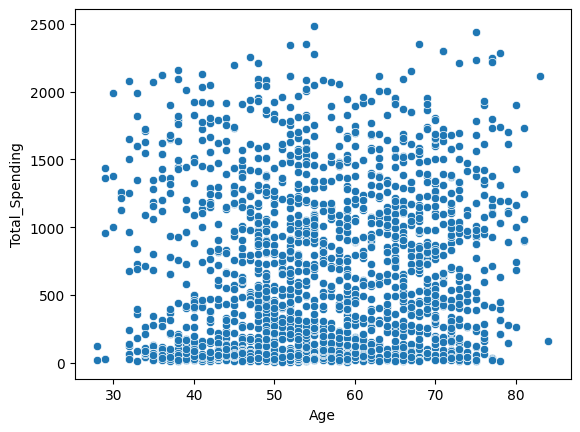

In [71]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.show()

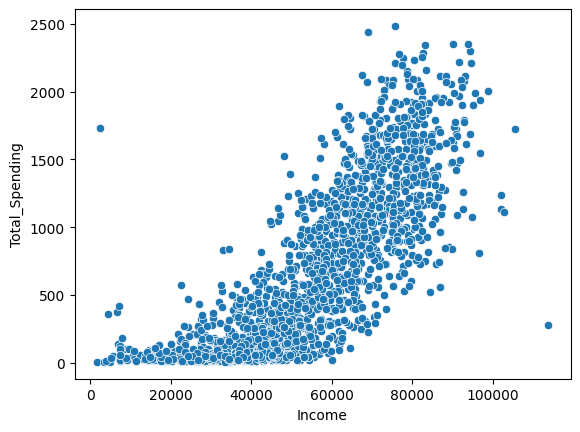

In [72]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.show()

3. Normalize numerical features (spending, income).

In [80]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
features = ["Income","Age","Total_Spending"]
X_scaled = std.fit_transform(df[features])

4. Choose optimal number of clusters using Elbow
method.


In [78]:
from sklearn.cluster import KMeans

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

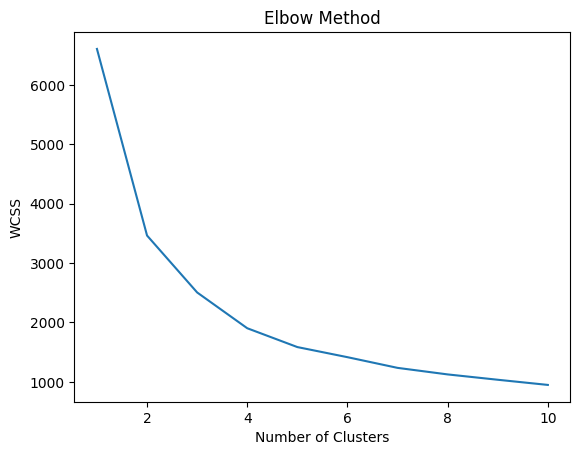

In [82]:
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

so , our graph maximum varies from 2 to 5 so we go with k = 4 

5. Apply K-Means clustering.


In [84]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_
df['Cluster'] = labels
print(df['Cluster'].value_counts())

Cluster
1    787
2    557
3    466
0    392
Name: count, dtype: int64


<Axes: >

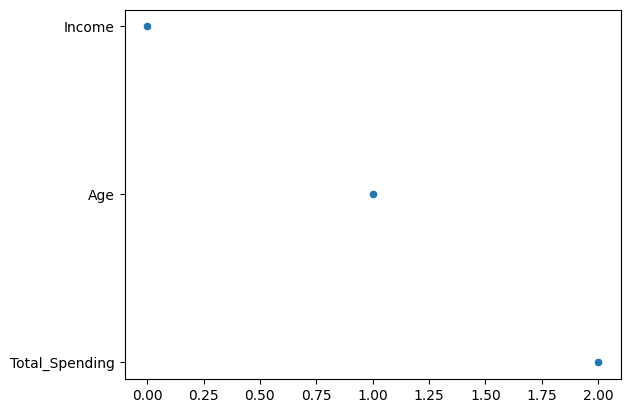